# Learning analysis

In [1]:
import os
import chess
import pandas as pd
import pickle
import numpy as np
from scipy import stats
from statsmodels.stats.weightstats import ttest_ind
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from collections import defaultdict
from datetime import datetime
from scipy.stats import binned_statistic
from scipy.optimize import curve_fit

In [2]:
# Increase font size a bit
plt.rcParams.update({'font.size': 16})

## Function definitions

In [3]:
def get_ordered_unique_values(a):
    x,c = np.unique(a,return_counts=True)
    x = x[np.argsort(c)[::-1]]
    c = np.sort(c)[::-1]
    return x,c

In [4]:
def get_mean_and_sem(x):
    return np.nanmean(x),np.nanstd(x)/np.sqrt(len(x))

In [5]:
def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c

## Queen's Gambit

In [6]:
# Load the csv data of QG games (October 2021 - March 2022)
direc = '../../Data/Learning/rep_queens_gambit/'

df = pd.concat([pd.read_csv(direc + 'df_{:d}_{:02d}.csv'.format(2021 + j//12,j%12+1),
                            usecols=['white','black','start_time','fourthmove','rt','result', 'blackelo', 'whiteelo',
                                     'num_black_games','num_white_games'])
                for j in range(9,15)],ignore_index=True)

In [7]:
# Load the pkl data of unique players (March 2021 - September 2021)
players = []
for i in range(3,9):
    with open(direc + 'QG_players_2021_{:02d}.pkl'.format(i),'rb') as f:
        players = pickle.load(f)
s = set(np.array(players).flatten())

# Filter out players who have played the QG in this period
df = df[df['black'].apply(lambda p: not p in s)].reset_index(drop=True)

In [8]:
# Add accept, decline (either the Slav Defense or QG Declined), other to df
df['fourthcode'] = df['fourthmove'].map({'d5c4' : 'A', 'e7e6' : 'D', 'c7c6' : 'D'}).fillna('O')

# Add move index to df
unique_fourthmoves,_ = get_ordered_unique_values(df['fourthmove'].astype(str))
move_to_index = {m:i for i,m in enumerate(unique_fourthmoves)}
df['fourthindex'] = np.array([move_to_index[m] for m in df['fourthmove'].astype(str)])

In [9]:
move_to_index

{'d5c4': 0,
 'e7e6': 1,
 'g8f6': 2,
 'c7c6': 3,
 'b8c6': 4,
 'e7e5': 5,
 'c7c5': 6,
 'c8f5': 7,
 'c8e6': 8,
 'g7g6': 9,
 'd8d6': 10,
 'b7b6': 11,
 'f7f6': 12,
 'c8g4': 13,
 'nan': 14,
 'f7f5': 15,
 'a7a6': 16,
 'h7h6': 17,
 'c8d7': 18,
 'b8d7': 19,
 'b8a6': 20,
 'a7a5': 21,
 'b7b5': 22,
 'h7h5': 23,
 'd8d7': 24,
 'g7g5': 25,
 'g8h6': 26,
 'e8d7': 27,
 'c8h3': 28}

In [10]:
# View the remaining data
df

,black,white,start_time,fourthmove,rt,result,blackelo,whiteelo,num_black_games,num_white_games,fourthcode,fourthindex
0,Vasquez_San22,LooseyGoosey6969,1.633072e+09,g8f6,1.0,1.0,990,1054,0,0,O,2
1,DanielBenesch,infoBacsi,1.633072e+09,g8f6,18.0,0.0,1175,1152,0,0,O,2
2,Abelpio,thebestplayer01,1.633072e+09,e7e5,6.0,0.5,842,878,0,0,O,5
3,samyrmismo,ebanayaroza,1.633072e+09,c7c6,2.0,1.0,1157,1192,0,0,D,3
4,Jazael319,TheAlterBoy,1.633072e+09,e7e6,2.0,1.0,1047,1019,0,0,D,1
...,...,...,...,...,...,...,...,...,...,...,...,...
522206,ccolwell,Damidee3,1.648796e+09,g8f6,4.0,1.0,1024,1057,0,0,O,2
522207,Kasporaf_omar,vasssyan,1.648796e+09,d5c4,0.0,1.0,970,1035,0,0,A,0
522208,Master_Cheeso,grn36,1.648796e+09,g8f6,7.0,0.0,953,921,0,0,O,2
522209,pansitoconquesito,creeffryer,1.648796e+09,d5c4,3.0,1.0,1016,995,0,0,A,0


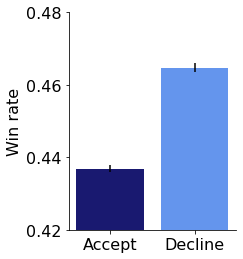

In [11]:
# Plot the overall win rate for accepting/declining the QG
fig, ax = plt.subplots(figsize=(3,4))

df_by_code = df[df['fourthcode'].isin(['A','D'])].groupby('fourthcode')['result'].agg(['mean','sem']).reset_index()
ax.bar(range(len(df_by_code)),1-df_by_code['mean'], color=['midnightblue', 'cornflowerblue'])
ax.errorbar(x=range(len(df_by_code)),y=1-df_by_code['mean'],yerr=df_by_code['sem'],linestyle='None',color='black')
ax.set_xticks(range(len(df_by_code)))
ax.set_xticklabels(['Accept', 'Decline'])
ax.set_yticks([0.42, 0.44, 0.46, 0.48])
ax.set_ylim([0.42,0.48])
ax.set_ylabel('Win rate')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig('winrate.png', format='png', dpi=1000,bbox_inches = 'tight')

In [12]:
# Test for significance
accept = [1-df['result'][icurr] for icurr in range(len(df)) if df['fourthcode'][icurr]=='A']
decline = [1-df['result'][icurr] for icurr in range(len(df)) if df['fourthcode'][icurr]=='D']
accept = np.asarray(accept)
decline = np.asarray(decline)
accept = accept[~np.isnan(accept)]
decline = decline[~np.isnan(decline)]

ttest_ind(accept, decline)

(-17.07543863328864, 2.397783285613093e-65, 364669.0)

In [14]:
# Report effect size
df_by_code['mean'][0]-df_by_code['mean'][1]

0.02785433609871879

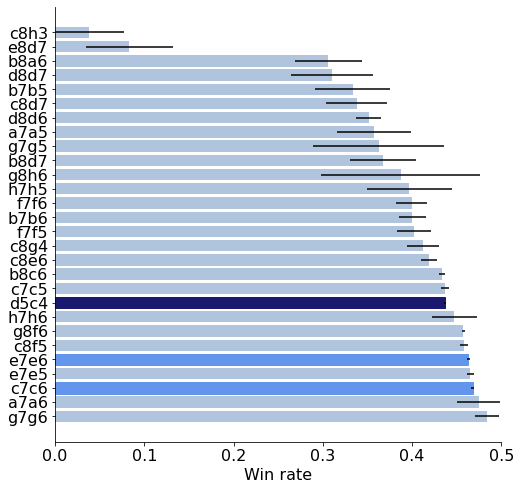

In [15]:
# Plot the win rate for different responses to the QG
fig, ax = plt.subplots(figsize=(8,8))

df_by_move = df.groupby('fourthmove')['result'].agg(['mean','sem']).sort_values('mean').reset_index()
barlist = ax.barh(range(len(df_by_move)),1-df_by_move['mean'], color='lightsteelblue')
ax.errorbar(y=range(len(df_by_move)),x=1-df_by_move['mean'],xerr=df_by_move['sem'],linestyle='None',color='black')
ax.set_yticks(range(len(df_by_move)))
ax.set_yticklabels(labels=df_by_move['fourthmove'])
ax.set_xlabel('Win rate')
ax.set_xlim(0,.5)
ax.set_xticks([0,0.1,0.2,0.3,0.4,0.5])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

barlist[8].set_color('midnightblue')
barlist[2].set_color('cornflowerblue')
barlist[4].set_color('cornflowerblue')

# plt.savefig('responses_winrate.png', format='png', dpi=1000,bbox_inches = 'tight')

In [16]:
# Create a binary dataframe of just accept/decline
df_binary = df[(df['fourthcode'].isin(['A','D'])) & (~df['result'].isna())].reset_index(drop=True)
names,ind = np.unique(df_binary['black'],return_inverse=True)
name_to_ind = dict(zip(names,ind))

df_binary

,black,white,start_time,fourthmove,rt,result,blackelo,whiteelo,num_black_games,num_white_games,fourthcode,fourthindex
0,samyrmismo,ebanayaroza,1.633072e+09,c7c6,2.0,1.0,1157,1192,0,0,D,3
1,Jazael319,TheAlterBoy,1.633072e+09,e7e6,2.0,1.0,1047,1019,0,0,D,1
2,sachithra_wijerathna,highnet,1.633072e+09,c7c6,-1.0,0.0,942,902,0,0,D,3
3,bermark,egdik,1.633072e+09,d5c4,2.0,1.0,972,1120,0,0,A,0
4,regianomartin,Sevak_Tavetian,1.633072e+09,e7e6,0.0,1.0,1110,1095,0,0,D,1
...,...,...,...,...,...,...,...,...,...,...,...,...
364666,figoss,Br1mass,1.648796e+09,c7c6,2.0,1.0,867,830,0,1,D,3
364667,kawulol,Kranfdlohtreb,1.648796e+09,c7c6,14.0,1.0,1169,1133,3,0,D,3
364668,Kasporaf_omar,vasssyan,1.648796e+09,d5c4,0.0,1.0,970,1035,0,0,A,0
364669,pansitoconquesito,creeffryer,1.648796e+09,d5c4,3.0,1.0,1016,995,0,0,A,0


In [17]:
# Compute the number of unique players that played the opening
len(np.unique(df_binary['black']))

112495

In [18]:
# Compute the percentage of moves that reduction contains
len(df_binary)/len(df)

0.6983211766891161

In [19]:
# Compute the index of the last game as black/white for each QG game
last_game_as_white = [None]*len(df_binary)
last_game_as_black = [None]*len(df_binary)

d_black = defaultdict(lambda: -1)
d_white = defaultdict(lambda: -1)

for i,row in df_binary.iterrows():
    
    last_game_as_white[i] = d_white[row['black']]
    last_game_as_black[i] = d_black[row['black']]
    d_white[row['white']] = i
    d_black[row['black']] = i
    
    if i%100000==0:
        print(i)

0
100000
200000
300000


In [20]:
# Add these to the dataframe
df_binary['last_game_as_white'] = last_game_as_white
df_binary['last_game_as_black'] = last_game_as_black

df_binary

,black,white,start_time,fourthmove,rt,result,blackelo,whiteelo,num_black_games,num_white_games,fourthcode,fourthindex,last_game_as_white,last_game_as_black
0,samyrmismo,ebanayaroza,1.633072e+09,c7c6,2.0,1.0,1157,1192,0,0,D,3,-1,-1
1,Jazael319,TheAlterBoy,1.633072e+09,e7e6,2.0,1.0,1047,1019,0,0,D,1,-1,-1
2,sachithra_wijerathna,highnet,1.633072e+09,c7c6,-1.0,0.0,942,902,0,0,D,3,-1,-1
3,bermark,egdik,1.633072e+09,d5c4,2.0,1.0,972,1120,0,0,A,0,-1,-1
4,regianomartin,Sevak_Tavetian,1.633072e+09,e7e6,0.0,1.0,1110,1095,0,0,D,1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
364666,figoss,Br1mass,1.648796e+09,c7c6,2.0,1.0,867,830,0,1,D,3,339458,256108
364667,kawulol,Kranfdlohtreb,1.648796e+09,c7c6,14.0,1.0,1169,1133,3,0,D,3,-1,-1
364668,Kasporaf_omar,vasssyan,1.648796e+09,d5c4,0.0,1.0,970,1035,0,0,A,0,-1,-1
364669,pansitoconquesito,creeffryer,1.648796e+09,d5c4,3.0,1.0,1016,995,0,0,A,0,-1,-1


In [21]:
# Compute the win-stay, lose-shift mean and sem for the QG
result = df_binary['result'].values
code = df_binary['fourthcode'].values

means = [get_mean_and_sem([code[icurr]==code[iprev] for icurr,iprev in enumerate(df_binary['last_game_as_black']) 
                           if iprev>=0 and result[iprev]==res]) for res in [1,0.5,0]]

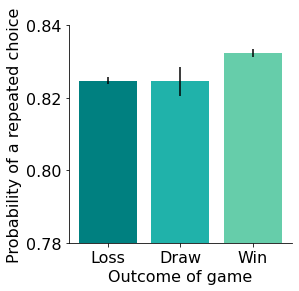

In [22]:
# Plot the win-stay, lose-shift probabilities for the QG
fig, ax = plt.subplots(figsize=(4,4))
colors = ['teal', 'lightseagreen', 'mediumaquamarine']

x = [1,2,3]
ax.bar(x,[m for m,s in means], color=[c for c in colors])
ax.errorbar(x,y=[m for m,s in means],yerr=[s for m,s in means],linestyle='None',color='black')
ax.set_xticks(x)
ax.set_xticklabels(['Loss','Draw','Win'])
ax.set_yticks([0.78,0.8,0.82,0.84])
ax.set_ylim([0.78,0.84])
ax.set_ylabel('Probability of a repeated choice')
ax.set_xlabel('Outcome of game')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig('RL_repeat.png', format='png', dpi=1000,bbox_inches = 'tight')

In [23]:
# Test for significance
loss = [code[icurr]==code[iprev] for icurr,iprev in enumerate(df_binary['last_game_as_black']) 
                           if iprev>=0 and result[iprev]==1]
win = [code[icurr]==code[iprev] for icurr,iprev in enumerate(df_binary['last_game_as_black']) 
                           if iprev>=0 and result[iprev]==0]

ttest_ind(loss, win)

(-5.023955692360605, 5.065362684977994e-07, 243464.0)

In [24]:
# Report effect size
means[0][0]-means[2][0]

-0.007718090192851856

In [25]:
# Repeat for the opponent's move
result = df_binary['result'].values
code = df_binary['fourthcode'].values

means = [get_mean_and_sem([code[icurr]==code[iprev] for icurr,iprev in enumerate(df_binary['last_game_as_white']) 
                           if iprev>=0 and result[iprev]==res]) for res in [0,0.5,1]]

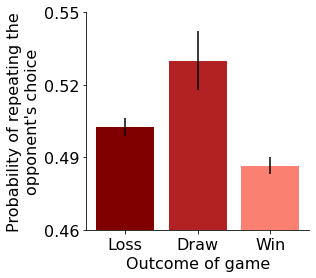

In [26]:
# Plot
fig, ax = plt.subplots(figsize=(4,4))
colors = ['maroon', 'firebrick', 'salmon']

x = [1,2,3]
ax.bar(x,[m for m,s in means], color=[c for c in colors])
ax.errorbar(x,y=[m for m,s in means],yerr=[s for m,s in means],linestyle='None',color='black')
ax.set_xticks(x)
ax.set_xticklabels(['Loss','Draw','Win'])
ax.set_yticks([0.46,0.49,0.52,.55])
ax.set_ylim([0.46,0.55])
ax.set_ylabel('Probability of repeating the\nopponent\'s choice')
ax.set_xlabel('Outcome of game')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig('opp_RL_repeat.png', format='png', dpi=1000,bbox_inches = 'tight')

In [27]:
# Test for significance
loss = [code[icurr]==code[iprev] for icurr,iprev in enumerate(df_binary['last_game_as_white']) 
                           if iprev>=0 and result[iprev]==0]
win = [code[icurr]==code[iprev] for icurr,iprev in enumerate(df_binary['last_game_as_white']) 
                           if iprev>=0 and result[iprev]==1]

ttest_ind(loss, win)

(3.1994899486948603, 0.0013777916575922933, 39690.0)

In [28]:
# Report effect size
means[0][0]-means[2][0]

0.016114379074972207

In [29]:
# Repeat for copy effect
result = df_binary['result'].values
code = df_binary['fourthcode'].values

means = [get_mean_and_sem([code[icurr]=='D' for icurr,iprev in enumerate(df_binary['last_game_as_white']) 
                           if iprev>=0 and code[iprev]==opp_code]) for opp_code in ['A','D']]

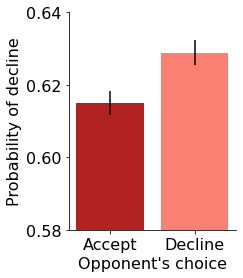

In [30]:
# Plot
fig, ax = plt.subplots(figsize=(3,4))
colors = ['firebrick', 'salmon']

x = [1,2]
ax.bar(x,[m for m,s in means], color=[c for c in colors])
ax.errorbar(x,y=[m for m,s in means],yerr=[s for m,s in means],linestyle='None',color='black')
ax.set_xticks(x)
ax.set_xticklabels(['Accept','Decline'])
ax.set_yticks([0.58,0.6,0.62,.64])
ax.set_ylim([0.58,0.64])
ax.set_ylabel('Probability of decline')
ax.set_xlabel('Opponent\'s choice')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig('opp_copy.png', format='png', dpi=1000,bbox_inches = 'tight')

In [31]:
# Test for significance
accept = [code[icurr]=='D' for icurr,iprev in enumerate(df_binary['last_game_as_white']) 
                           if iprev>=0 and code[iprev]=='A']
decline = [code[icurr]=='D' for icurr,iprev in enumerate(df_binary['last_game_as_white']) 
                           if iprev>=0 and code[iprev]=='D']

ttest_ind(accept, decline)

(-2.8962343198372364, 0.003778683105337913, 41320.0)

In [33]:
# Report effect size
means[0][0]-means[1][0]

-0.013883898962891994

In [86]:
# Compute the index of the nth QG game back as black
nback = last_game_as_black
for n in range(1,31):
    df_binary['black_game_' + str(n) + '_back'] = nback
    nback = [last_game_as_black[i] if i>=0 else -1 for i in nback]

In [87]:
df_binary

,black,white,start_time,fourthmove,rt,result,blackelo,whiteelo,num_black_games,num_white_games,...,black_game_21_back,black_game_22_back,black_game_23_back,black_game_24_back,black_game_25_back,black_game_26_back,black_game_27_back,black_game_28_back,black_game_29_back,black_game_30_back
0,samyrmismo,ebanayaroza,1.633072e+09,c7c6,2.0,1.0,1157,1192,0,0,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
1,Jazael319,TheAlterBoy,1.633072e+09,e7e6,2.0,1.0,1047,1019,0,0,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
2,sachithra_wijerathna,highnet,1.633072e+09,c7c6,-1.0,0.0,942,902,0,0,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
3,bermark,egdik,1.633072e+09,d5c4,2.0,1.0,972,1120,0,0,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
4,regianomartin,Sevak_Tavetian,1.633072e+09,e7e6,0.0,1.0,1110,1095,0,0,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
364666,figoss,Br1mass,1.648796e+09,c7c6,2.0,1.0,867,830,0,1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
364667,kawulol,Kranfdlohtreb,1.648796e+09,c7c6,14.0,1.0,1169,1133,3,0,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
364668,Kasporaf_omar,vasssyan,1.648796e+09,d5c4,0.0,1.0,970,1035,0,0,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
364669,pansitoconquesito,creeffryer,1.648796e+09,d5c4,3.0,1.0,1016,995,0,0,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


In [88]:
# Compute the win-stay, lose-shift mean and sem for the QG 2 games back
rl_probs = np.zeros((4,4))
rl_count = np.zeros((4,4))
rl_vals = [[] for x in range(16)]

result = df_binary['result'].values
code = df_binary['fourthcode'].values

# Loop through the dataframe
for ind in df_binary.index:
    
    # Grab the previous 2 indices, results, and codes as black
    res = df_binary['result'][ind]
    iprev1 = df_binary['black_game_1_back'][ind]
    iprev2 = df_binary['black_game_2_back'][ind]
    res1 = result[iprev1]
    res2 = result[iprev2]
    code1 = code[iprev1]
    code2 = code[iprev2]
    
    # If there is a 2 game history
    if iprev1 >= 0 and iprev2 >= 0:
        
        # Check if there was a repetition
        if code[ind] == code1:
            repeat = 1
        else:
            repeat = 0
        
        # Assign it to the correct part of the array
        if code2 == 'A' and res2 == 1 and code1 == 'A' and res1 == 1:
            rl_vals[0].append(repeat)
        elif code2 == 'A' and res2 == 1 and code1 == 'A' and res1 == 0:
            rl_vals[1].append(repeat)
        elif code2 == 'A' and res2 == 1 and code1 == 'D' and res1 == 1:
            rl_vals[2].append(repeat)
        elif code2 == 'A' and res2 == 1 and code1 == 'D' and res1 == 0:
            rl_vals[3].append(repeat)
            
        elif code2 == 'A' and res2 == 0 and code1 == 'A' and res1 == 1:
            rl_vals[4].append(repeat)
        elif code2 == 'A' and res2 == 0 and code1 == 'A' and res1 == 0:
            rl_vals[5].append(repeat)
        elif code2 == 'A' and res2 == 0 and code1 == 'D' and res1 == 1:
            rl_vals[6].append(repeat)
        elif code2 == 'A' and res2 == 0 and code1 == 'D' and res1 == 0:
            rl_vals[7].append(repeat)
            
        elif code2 == 'D' and res2 == 1 and code1 == 'A' and res1 == 1:
            rl_vals[8].append(repeat)
        elif code2 == 'D' and res2 == 1 and code1 == 'A' and res1 == 0:
            rl_vals[9].append(repeat)
        elif code2 == 'D' and res2 == 1 and code1 == 'D' and res1 == 1:
            rl_vals[10].append(repeat)
        elif code2 == 'D' and res2 == 1 and code1 == 'D' and res1 == 0:
            rl_vals[11].append(repeat)
            
        elif code2 == 'D' and res2 == 0 and code1 == 'A' and res1 == 1:
            rl_vals[12].append(repeat)
        elif code2 == 'D' and res2 == 0 and code1 == 'A' and res1 == 0:
            rl_vals[13].append(repeat)
        elif code2 == 'D' and res2 == 0 and code1 == 'D' and res1 == 1:
            rl_vals[14].append(repeat)
        elif code2 == 'D' and res2 == 0 and code1 == 'D' and res1 == 0:
            rl_vals[15].append(repeat)


In [89]:
# Compute all combinations of the probabilities
means = []
sems = []

for i in range(16):
    means.append(np.mean(rl_vals[i]))
    sems.append(stats.sem(rl_vals[i]))
    
means

[0.8978059625337124,
 0.9038373056041226,
 0.5218124341412013,
 0.526876393361407,
 0.8973640705363704,
 0.9016336461591936,
 0.5152628603730921,
 0.5363908275174477,
 0.5735391400220508,
 0.5888353641258147,
 0.88526013128628,
 0.8844955081586506,
 0.5675459632294164,
 0.5861497680583168,
 0.8893874244407054,
 0.8909166608840469]

In [90]:
# Generate a colormap
data = [i for i in range(18)]
denominator = max(data) - min(data)
scaled_data = [(datum-min(data))/denominator for datum in data]
colors = []
cmap = plt.cm.get_cmap('Greens_r')
for decimal in scaled_data:
    colors.append(cmap(decimal))

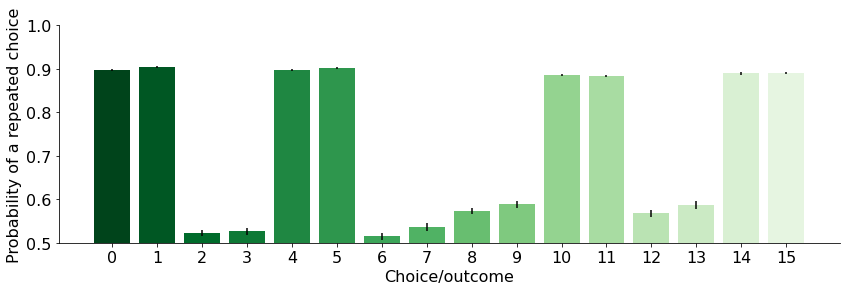

In [95]:
# Plot
fig, ax = plt.subplots(figsize=(14,4))
ax.bar(np.arange(16), means, color=colors)
ax.errorbar(np.arange(16), means,yerr=sems,linestyle='None',color='black')
ax.set_xticks(np.arange(16))
ax.set_ylim([0.5,1])
ax.set_ylabel('Probability of a repeated choice')
ax.set_xlabel('Choice/outcome')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig('RL_tree.png', format='png', dpi=1000,bbox_inches = 'tight')

In [96]:
# Test for significance (stay vs. shift with same outcomes and initial choice)
print(ttest_ind(rl_vals[0], rl_vals[2]))
print(ttest_ind(rl_vals[1], rl_vals[3]))
print(ttest_ind(rl_vals[4], rl_vals[6]))
print(ttest_ind(rl_vals[5], rl_vals[7]))
print(ttest_ind(rl_vals[8], rl_vals[10]))
print(ttest_ind(rl_vals[9], rl_vals[11]))
print(ttest_ind(rl_vals[12], rl_vals[14]))
print(ttest_ind(rl_vals[13], rl_vals[15]))

(70.51407817649486, 0.0, 32181.0)
(65.61873397175542, 0.0, 25769.0)
(62.39274172902837, 0.0, 25312.0)
(55.134312502799474, 0.0, 20269.0)
(-52.19305969734001, 0.0, 22966.0)
(-44.69956179253722, 0.0, 19890.0)
(-49.952188572155805, 0.0, 19798.0)
(-43.520371810427676, 0.0, 17427.0)


In [97]:
# Test for significance (loss vs. win on last game)
print(ttest_ind(rl_vals[0], rl_vals[1]))
print(ttest_ind(rl_vals[2], rl_vals[3]))
print(ttest_ind(rl_vals[4], rl_vals[5]))
print(ttest_ind(rl_vals[6], rl_vals[7]))
print(ttest_ind(rl_vals[8], rl_vals[9]))
print(ttest_ind(rl_vals[10], rl_vals[11]))
print(ttest_ind(rl_vals[12], rl_vals[13]))
print(ttest_ind(rl_vals[14], rl_vals[15]))

(-2.218737647543205, 0.026509126504645944, 49170.0)
(-0.47351507830962114, 0.6358575189518767, 8780.0)
(-1.3919264589274496, 0.16395259889347422, 39036.0)
(-1.706196897402964, 0.08801886770450305, 6545.0)
(-1.3807517256385713, 0.16739358657152542, 8062.0)
(0.22305719666273235, 0.8234923005918521, 34794.0)
(-1.5396433406266936, 0.12369405723839198, 6769.0)
(-0.42604524829869234, 0.6700778859039325, 30456.0)


In [98]:
# Create an array with the outcomes of the previous games
X = np.array([[0.5 if iprev==-1 else 
               (df_binary['result'][iprev] if df_binary['fourthcode'][iprev]=='D' else 1-df_binary['result'][iprev]) 
               for iprev in df_binary['black_game_' + str(n) + '_back']] for n in range(1,31)])

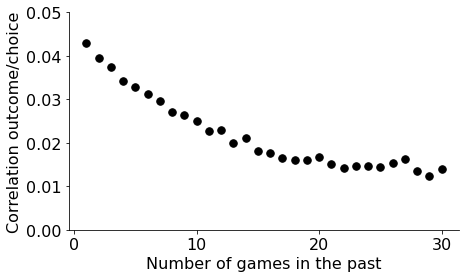

In [101]:
# Plot the correlation between outcome of previous games and choice to accept in current game
fig, ax = plt.subplots(figsize=(7,4))

ax.plot(range(1,31),[np.corrcoef(X[n,:],df_binary['fourthcode']=='D')[0,1] for n in range(30)],'.',markersize=15, color='black')
ax.set_xlabel('Number of games in the past')
ax.set_ylabel('Correlation outcome/choice')
ax.set_yticks(np.arange(0,1,0.01))
ax.set_xticks([0,10,20,30])
ax.set_ylim([0,0.05])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig('RL_corr.png', format='png', dpi=1000,bbox_inches = 'tight')

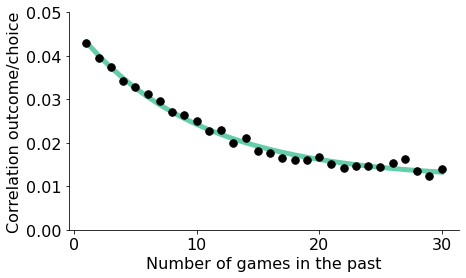

In [102]:
# Same plot with an exponential fit
popt, pcov = curve_fit(exp_func, range(1,31), [np.corrcoef(X[n,:],df_binary['fourthcode']=='D')[0,1] for n in range(30)])

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(range(1,31), exp_func(range(1,31), *popt), lw=5, color='mediumaquamarine')
ax.plot(range(1,31),[np.corrcoef(X[n,:],df_binary['fourthcode']=='D')[0,1] for n in range(30)],'.',markersize=15, color='black')
ax.set_xlabel('Number of games in the past')
ax.set_ylabel('Correlation outcome/choice')
ax.set_yticks(np.arange(0,1,0.01))
ax.set_xticks([0,10,20,30])
ax.set_ylim([0,0.05])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig('RL_corr.png', format='png', dpi=1000,bbox_inches = 'tight')

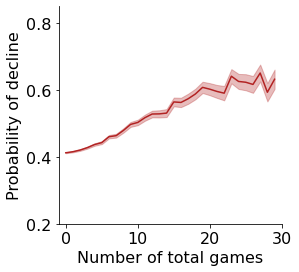

In [103]:
# Plot the probability of choices depending on the number of previous QG games (irrespective of color)
fig, ax = plt.subplots(figsize=(4,4))

n_games = 30
code = 'D'
m = np.array([get_mean_and_sem(df_binary[(df_binary['num_black_games'] + df_binary['num_white_games'])==i]['fourthcode']==code) for i in range(n_games)])
ax.plot(m[:,0], color='firebrick')
ax.fill_between(range(n_games), m[:,0]-m[:,1],m[:,0]+m[:,1], alpha=0.3, color='firebrick')
    
ax.set_xlabel('Number of total games')
ax.set_ylabel('Probability of decline')
ax.set_xticks([0, 10, 20, 30])
ax.set_yticks([.2, .4, .6, .8])
ax.set_xlim(-1,n_games)
ax.set_ylim(0.2,0.85)
# ax.legend(bbox_to_anchor=(1,1), frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig('prob_all.png', format='png', dpi=1000,bbox_inches = 'tight')

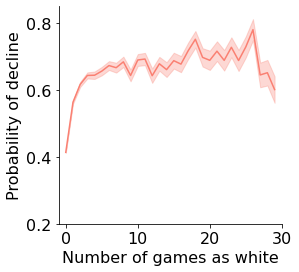

In [104]:
# Plot the probability of choices depending on the number of previous white QG games
fig, ax = plt.subplots(figsize=(4,4))

m = np.array([get_mean_and_sem(df_binary[df_binary['num_white_games']==i]['fourthcode']==code) for i in range(n_games)])
ax.plot(m[:,0], color='salmon')
ax.fill_between(range(n_games),m[:,0]-m[:,1],m[:,0]+m[:,1], alpha=0.3, color='salmon')
    
ax.set_xlabel('Number of games as white')
ax.set_ylabel('Probability of decline')
ax.set_xticks([0, 10, 20, 30])
ax.set_yticks([.2, .4, .6, .8])
ax.set_xlim(-1,n_games)
ax.set_ylim(0.2,0.85)
# ax.legend(bbox_to_anchor=(1,1), frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig('prob_white.png', format='png', dpi=1000,bbox_inches = 'tight')

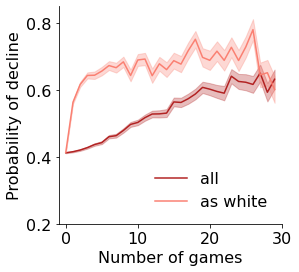

In [105]:
# Plot the probability of choices depending on the number of previous total + white QG games
fig, ax = plt.subplots(figsize=(4,4))

m = np.array([get_mean_and_sem(df_binary[(df_binary['num_black_games'] + df_binary['num_white_games'])==i]['fourthcode']==code) for i in range(n_games)])
ax.plot(m[:,0], color='firebrick', label='all')
ax.fill_between(range(n_games), m[:,0]-m[:,1],m[:,0]+m[:,1], alpha=0.3, color='firebrick')

m = np.array([get_mean_and_sem(df_binary[df_binary['num_white_games']==i]['fourthcode']==code) for i in range(n_games)])
ax.plot(m[:,0], color='salmon', label='as white')
ax.fill_between(range(n_games),m[:,0]-m[:,1],m[:,0]+m[:,1], alpha=0.3, color='salmon')
    
ax.set_xlabel('Number of games')
ax.set_ylabel('Probability of decline')
ax.set_xticks([0, 10, 20, 30])
ax.set_yticks([.2, .4, .6, .8])
ax.set_xlim(-1,n_games)
ax.set_ylim(0.2,0.85)
ax.legend(loc='lower right', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig('prob_split.png', format='png', dpi=1000,bbox_inches = 'tight')

In [106]:
# Compute the mean and sem binned for response time vs. probability of decline
all_rt = df_binary.loc[df_binary['rt'] >= 0]['rt'].values
all_codes = df_binary.loc[df_binary['rt'] >= 0]['fourthcode'].values
all_codes_binary = np.where(all_codes == 'D', 1, 0)

bin_means, bin_edges, binnumber = binned_statistic(all_rt, all_codes_binary, statistic='mean', bins=10, range=(0, 10))
bin_sem, bin_edges_sem, binnumber_sem = binned_statistic(all_rt, all_codes_binary, statistic=stats.sem, bins=10, range=(0, 10))

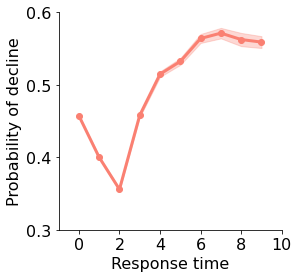

In [107]:
# Plot
fig, ax = plt.subplots(figsize=(4,4))

ax.errorbar(bin_edges[:-1], bin_means, marker='o', color='salmon', lw=3)
ax.fill_between(bin_edges[:-1], bin_means-bin_sem, bin_means+bin_sem, color='salmon', alpha=0.3)
ax.set_ylabel('Probability of decline')
ax.set_xlabel('Response time')
ax.set_xlim(-1, 10)
ax.set_ylim(0.3,0.6)
ax.set_xticks([0, 2, 4, 6, 8, 10])
ax.set_yticks([0.3, 0.4, 0.5, 0.6])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig('rt_decline.png', format='png', dpi=1000,bbox_inches = 'tight')

In [108]:
# Compute the mean and sem binned for elo rating vs. probability of decline
all_elo = df_binary.loc[df_binary['blackelo'] >= 0]['blackelo'].values
all_codes = df_binary.loc[df_binary['blackelo'] >= 0]['fourthcode'].values
all_codes_binary = np.where(all_codes == 'D', 1, 0)

bin_means, bin_edges, binnumber = binned_statistic(all_elo, all_codes_binary, statistic='mean', bins=10, range=(800, 1200))
bin_sem, bin_edges_sem, binnumber_sem = binned_statistic(all_elo, all_codes_binary, statistic=stats.sem, bins=10, range=(800, 1200))

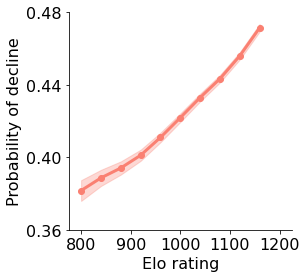

In [112]:
# Plot
fig, ax = plt.subplots(figsize=(4,4))

ax.errorbar(bin_edges[:-1], bin_means, marker='o', color='salmon', lw=3)
ax.fill_between(bin_edges[:-1], bin_means-bin_sem, bin_means+bin_sem, color='salmon', alpha=0.3)
ax.set_ylabel('Probability of decline')
ax.set_xlabel('Elo rating')
ax.set_xlim(775, 1225)
ax.set_ylim(0.36,0.48)
ax.set_xticks([800, 900, 1000, 1100, 1200])
ax.set_yticks([0.36, .4, .44, .48])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig('elo_decline.png', format='png', dpi=1000,bbox_inches = 'tight')

In [113]:
# Loop through the dataframe and compute time gap from last game as black/white
gap_black = []
gap_white = []

for ind in df_binary.index:
    
    # Grab the previous indices
    iprev_black = df_binary['last_game_as_black'][ind]
    iprev_white = df_binary['last_game_as_white'][ind]
    
    # Compute the time difference in seconds
    if iprev_black >= 0:
        curr_time = df_binary['start_time'][ind]
        prev_time = df_binary['start_time'][iprev_black]
        gap_black.append(curr_time-prev_time)
        
    else:
        gap_black.append(-1)
        
    if iprev_white >= 0:
        curr_time = df_binary['start_time'][ind]
        prev_time = df_binary['start_time'][iprev_white]
        gap_white.append(curr_time-prev_time)
        
    else:
        gap_white.append(-1)

In [114]:
# Add the time gap to the dataframe
df_binary['gap_black'] = gap_black
df_binary['gap_white'] = gap_white

In [115]:
df_binary

,black,white,start_time,fourthmove,rt,result,blackelo,whiteelo,num_black_games,num_white_games,...,black_game_23_back,black_game_24_back,black_game_25_back,black_game_26_back,black_game_27_back,black_game_28_back,black_game_29_back,black_game_30_back,gap_black,gap_white
0,samyrmismo,ebanayaroza,1.633072e+09,c7c6,2.0,1.0,1157,1192,0,0,...,-1,-1,-1,-1,-1,-1,-1,-1,-1.0,-1.0
1,Jazael319,TheAlterBoy,1.633072e+09,e7e6,2.0,1.0,1047,1019,0,0,...,-1,-1,-1,-1,-1,-1,-1,-1,-1.0,-1.0
2,sachithra_wijerathna,highnet,1.633072e+09,c7c6,-1.0,0.0,942,902,0,0,...,-1,-1,-1,-1,-1,-1,-1,-1,-1.0,-1.0
3,bermark,egdik,1.633072e+09,d5c4,2.0,1.0,972,1120,0,0,...,-1,-1,-1,-1,-1,-1,-1,-1,-1.0,-1.0
4,regianomartin,Sevak_Tavetian,1.633072e+09,e7e6,0.0,1.0,1110,1095,0,0,...,-1,-1,-1,-1,-1,-1,-1,-1,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
364666,figoss,Br1mass,1.648796e+09,c7c6,2.0,1.0,867,830,0,1,...,-1,-1,-1,-1,-1,-1,-1,-1,4062616.0,903762.0
364667,kawulol,Kranfdlohtreb,1.648796e+09,c7c6,14.0,1.0,1169,1133,3,0,...,-1,-1,-1,-1,-1,-1,-1,-1,-1.0,-1.0
364668,Kasporaf_omar,vasssyan,1.648796e+09,d5c4,0.0,1.0,970,1035,0,0,...,-1,-1,-1,-1,-1,-1,-1,-1,-1.0,-1.0
364669,pansitoconquesito,creeffryer,1.648796e+09,d5c4,3.0,1.0,1016,995,0,0,...,-1,-1,-1,-1,-1,-1,-1,-1,-1.0,-1.0


In [116]:
# Compute the gap irrespective of color
time = []
time_codes = []

for ind in df_binary.index:
    
    gap_black = df_binary['gap_black'][ind]
    gap_white = df_binary['gap_white'][ind]
    min_time = min(gap_black, gap_white)
    max_time = max(gap_black, gap_white)
    
    if min_time >= 0:
        time.append(min_time)
        time_codes.append(df_binary['fourthcode'][ind])
    elif max_time >= 0:
        time.append(max_time)
        time_codes.append(df_binary['fourthcode'][ind])        

In [117]:
# Compute the mean and sem binned for gap vs. probability of decline
time_codes_binary = np.where(np.asarray(time_codes) == 'D', 1, 0)

bin_means, bin_edges, binnumber = binned_statistic(np.asarray(time)/(60*60*24), time_codes_binary, statistic='mean', bins=10, range=(0, 20))
bin_sem, bin_edges_sem, binnumber_sem = binned_statistic(np.asarray(time)/(60*60*24), time_codes_binary, statistic=stats.sem, bins=10, range=(0, 20))

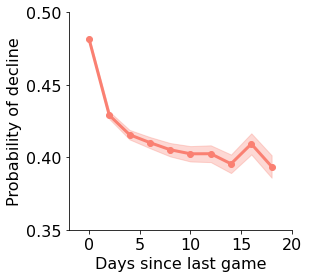

In [118]:
fig, ax = plt.subplots(figsize=(4,4))

ax.errorbar(bin_edges[:-1], bin_means, marker='o', color='salmon', lw=3)
ax.fill_between(bin_edges[:-1], bin_means-bin_sem, bin_means+bin_sem, color='salmon', alpha=0.3)
ax.set_ylabel('Probability of decline')
ax.set_xlabel('Days since last game')
ax.set_xlim(-2, 20)
ax.set_ylim(0.35,0.5)
ax.set_xticks([0, 5, 10, 15, 20])
ax.set_yticks([0.35, 0.4, .45, 0.5])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig('time_decline.png', format='png', dpi=1000,bbox_inches = 'tight')

In [119]:
# Loop through the dataframe and compute if there was a shift in choice
shift = []

for ind in df_binary.index:
    
    # Grab the previous index and current choice
    iprev_black = df_binary['last_game_as_black'][ind]
    curr_choice = df_binary['fourthcode'][ind]
    
    # Compute the shift
    if iprev_black >= 0:
        prev_choice = df_binary['fourthcode'][iprev_black]
        if prev_choice == curr_choice:
            shift.append(0)
        else:
            shift.append(1)
    else:
        shift.append(-1)

In [120]:
# Add the shift to the dataframe
df_binary['shift'] = shift

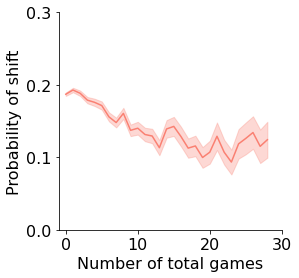

In [121]:
# Plot the probability of changing a shift depending on the number of previous QG games (irrespective of color)
fig, ax = plt.subplots(figsize=(4,4))

m = np.array([get_mean_and_sem(df_binary[((df_binary['num_black_games'] + df_binary['num_white_games'])==i) & (df_binary['fourthcode']==code)]['shift']==1) for i in range(n_games)])
ax.plot(m[1:,0], color='salmon')
ax.fill_between(range(n_games-1),m[1:,0]-m[1:,1],m[1:,0]+m[1:,1], alpha=0.3, color='salmon')
    
ax.set_xlabel('Number of total games')
ax.set_ylabel('Probability of shift')
ax.set_xticks([0, 10, 20, 30])
ax.set_yticks([0, .1, .2, .3])
ax.set_xlim(-1,n_games)
ax.set_ylim(0,0.3)
# ax.legend(bbox_to_anchor=(1,1), frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig('prob_shift.png', format='png', dpi=1000,bbox_inches = 'tight')